In [1]:
import sys
import torch

sys.path.append('..')

from PySESM.models.SESM.SESM import SESM_Model
from PySESM.test_functions.MultivariateNormal import MultivariateNormal
from PySESM.base_functions.Function import GaussianFunctions

In [2]:
n_samples = 2000
n_features = 3
l_functions = 20

In [3]:
mu_1 = torch.tensor([1, 1, 1])
mu_2 = torch.tensor([1, -1, 1])
mu_3 = torch.tensor([-1, -1, -1])

sigma_1 = 0.15 * torch.eye(n_features)
sigma_2 = 0.2 * torch.eye(n_features)
sigma_3 = 0.3 * torch.eye(n_features)

means = [mu_1, mu_2, mu_3]
covariances = [sigma_1, sigma_2, sigma_3]
scale_factors = [1.0, .5, 1.5]

In [4]:
mvn_1 = MultivariateNormal(n_features, means, covariances, scale_factors)

In [5]:
X, y = mvn_1.sample_n(n_samples)

print(X.shape)
print(y.shape)

torch.Size([2000, 3])
torch.Size([2000])


/home/rijegaro/.local/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
gaussian_function = GaussianFunctions(n_features=n_features, n_functions=l_functions)

In [7]:
model = SESM_Model(
    n_samples=n_samples,
    n_features=n_features,
    n_functions=l_functions,
    psi=gaussian_function.gaussian
)

In [8]:
model_epochs = 50
ista_epochs = 100   
dictionary_epochs = 60

ista_alpha = 0.02
ista_lambd = 0.001

dictionary_alpha = 0.02

model.fit(
    X=X,
    y=y,
    model_epochs=model_epochs,
    ista_epochs=ista_epochs,
    ista_alpha=ista_alpha,
    ista_lambd=ista_lambd,
    dictionary_epochs=dictionary_epochs,
    dictionary_alpha=dictionary_alpha
)

Epoch 1 Loss: 2.093485116958618

Epoch 2 Loss: 0.5906820893287659

Epoch 3 Loss: 0.26921820640563965

Epoch 4 Loss: 0.14523188769817352

Epoch 5 Loss: 0.08617696911096573

Epoch 6 Loss: 0.05510445311665535

Epoch 7 Loss: 0.03786017745733261

Epoch 8 Loss: 0.027890900149941444

Epoch 9 Loss: 0.02194998599588871

Epoch 10 Loss: 0.018288932740688324

Epoch 11 Loss: 0.015957921743392944

Epoch 12 Loss: 0.014422256499528885

Epoch 13 Loss: 0.013376925140619278

Epoch 14 Loss: 0.01263020746409893

Epoch 15 Loss: 0.012080803513526917

Epoch 16 Loss: 0.011661556549370289

Epoch 17 Loss: 0.011326472274959087

Epoch 18 Loss: 0.011051744222640991

Epoch 19 Loss: 0.010822052136063576

Epoch 20 Loss: 0.010626811534166336

Epoch 21 Loss: 0.010458682663738728

Epoch 22 Loss: 0.010316180065274239

Epoch 23 Loss: 0.010190323926508427

Epoch 24 Loss: 0.010077822022140026

Epoch 25 Loss: 0.00997626967728138

Epoch 26 Loss: 0.009883838705718517

Epoch 27 Loss: 0.009799118153750896

Epoch 28 Loss: 0.009722

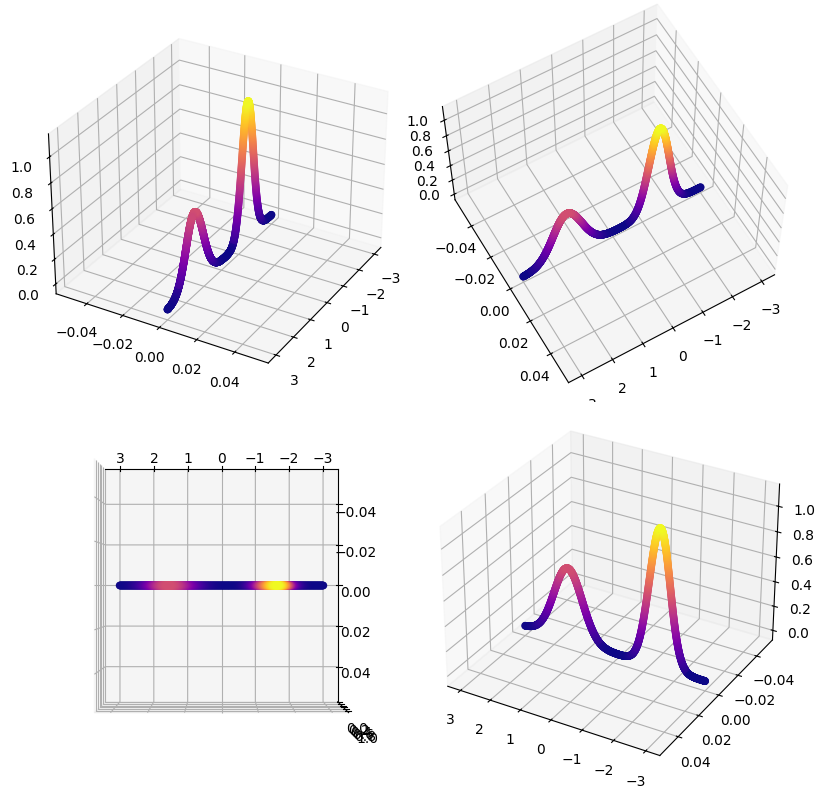

In [9]:
mvn_1.plot(n_samples)

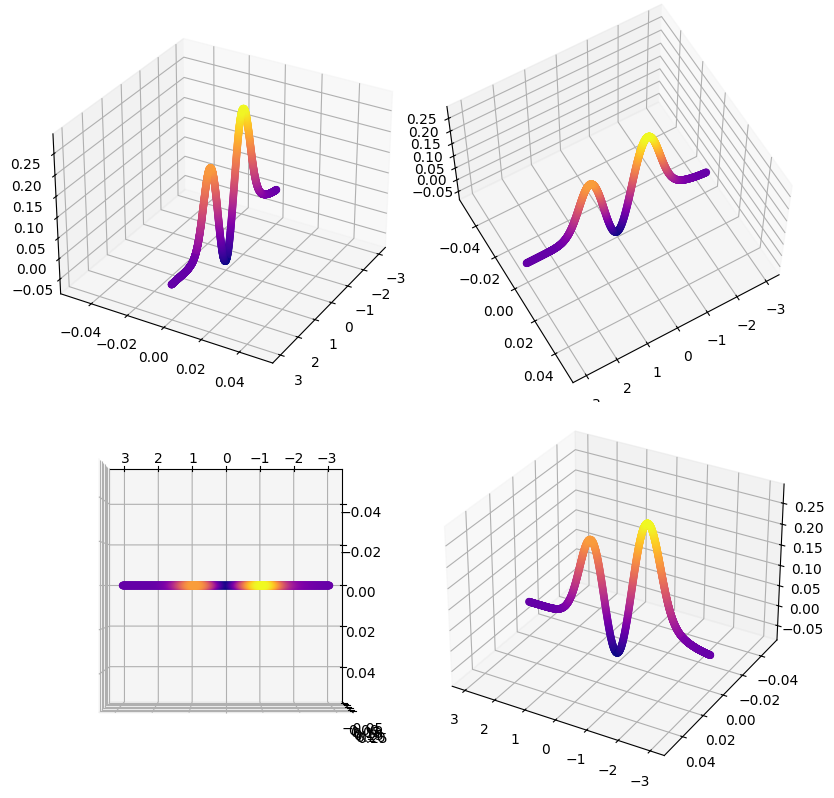

In [10]:
model.plot_function()

In [11]:
print(f'Duración del modelo: {model.time / 60:.2f} minutos')

Duración del modelo: 0.19 minutos


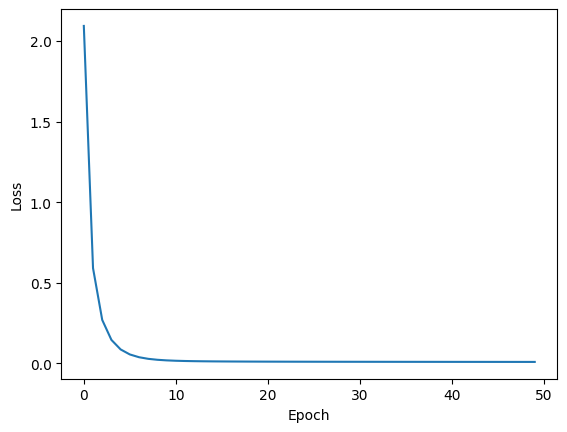

In [12]:
model.plot_loss()